# Data Quality Assessment — NovaCred Credit Applications

**Course:** Data Ecosystems and Governance in Organizations (DEGO 2606)
**Institution:** Nova School of Business and Economics — MSc Business Analytics
**Role:** Data Engineer

---

## Data Engineer Responsibilities

| Task | Description |
|---|---|
| Data loading | Read raw JSON, inspect schema and record count |
| Data profiling | Summarise field coverage, value distributions |
| Quality assessment | Check completeness, uniqueness, consistency, validity |
| Cleaning (in-memory) | Standardise encodings, normalise formats |
| Before / after summary | Quantify the effect of each cleaning step |

## 0. Setup

In [2]:
import json
import os
import re
import copy
from collections import Counter
from datetime import datetime
from pprint import pprint

import pandas as pd

In [3]:
# Locate data file
for _p in [os.path.join("Data", "raw_credit_applications.json"),
           os.path.join("..", "Data", "raw_credit_applications.json")]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError("raw_credit_applications.json not found")

with open(DATA_PATH, encoding="utf-8") as f:
    records = json.load(f)

# Flatten nested structure (as prof did in DataLakeExercise)
df = pd.json_normalize(records)

print(f"Data file : {DATA_PATH}")
print(f"Records   : {len(records)}")
print(f"Columns   : {df.shape[1]}")

Data file : ..\Data\raw_credit_applications.json
Records   : 502
Columns   : 21


In [4]:
# isna() alone does not catch fields that are present but blank (e.g. gender = "").
# We first identify how many such hidden gaps exist, then resolve them to NaN
# so that all downstream completeness checks reflect true missingness.

n_hidden_blanks = 0
hidden_blank_detail = {}

for col in df.select_dtypes(include="object").columns:
    n_blank = int(
        (df[col].fillna("").str.strip() == "").sum()
        - df[col].isna().sum()
    )
    if n_blank > 0:
        hidden_blank_detail[col] = n_blank
        n_hidden_blanks += n_blank

print(f"Hidden blank strings (present but empty — missed by isna): {n_hidden_blanks}")
if hidden_blank_detail:
    print(f"  {'Field':<44}  {'Count':>6}")
    print("  " + "-" * 54)
    for col, n in sorted(hidden_blank_detail.items(), key=lambda x: -x[1]):
        print(f"  {col:<44}  {n:>6}")

# Normalise: strip whitespace then replace empty strings with NaN across all text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().replace("", float("nan"))

print(f"\n{n_hidden_blanks} blank strings replaced with NaN — all subsequent checks reflect true missingness.")

Hidden blank strings (present but empty — missed by isna): 14
  Field                                          Count
  ------------------------------------------------------
  applicant_info.email                               7
  applicant_info.date_of_birth                       4
  applicant_info.gender                              2
  applicant_info.zip_code                            1

14 blank strings replaced with NaN — all subsequent checks reflect true missingness.


## 1. Dataset Profile

In [5]:
approved = int(df['decision.loan_approved'].sum())
rejected  = len(df) - approved

print("Dataset Profile:")
print(f"  Total records : {len(df)}")
print(f"  Approved      : {approved}  ({approved/len(df)*100:.1f}%)")
print(f"  Rejected      : {rejected}  ({rejected/len(df)*100:.1f}%)")
print()
print("  All columns:")
for c in df.columns:
    print(f"    {c}")

Dataset Profile:
  Total records : 502
  Approved      : 292  (58.2%)
  Rejected      : 210  (41.8%)

  All columns:
    _id
    spending_behavior
    processing_timestamp
    applicant_info.full_name
    applicant_info.email
    applicant_info.ssn
    applicant_info.ip_address
    applicant_info.gender
    applicant_info.date_of_birth
    applicant_info.zip_code
    financials.annual_income
    financials.credit_history_months
    financials.debt_to_income
    financials.savings_balance
    decision.loan_approved
    decision.rejection_reason
    loan_purpose
    decision.interest_rate
    decision.approved_amount
    financials.annual_salary
    notes


In [6]:
# Preview one document
print("Sample record:")
pprint(records[0])

Sample record:
{'_id': 'app_200',
 'applicant_info': {'date_of_birth': '2001-03-09',
                    'email': 'jerry.smith17@hotmail.com',
                    'full_name': 'Jerry Smith',
                    'gender': 'Male',
                    'ip_address': '192.168.48.155',
                    'ssn': '596-64-4340',
                    'zip_code': '10036'},
 'decision': {'loan_approved': False,
              'rejection_reason': 'algorithm_risk_score'},
 'financials': {'annual_income': 73000,
                'credit_history_months': 23,
                'debt_to_income': 0.2,
                'savings_balance': 31212},
 'processing_timestamp': '2024-01-15T00:00:00Z',
 'spending_behavior': [{'amount': 480, 'category': 'Shopping'},
                       {'amount': 790, 'category': 'Rent'},
                       {'amount': 247, 'category': 'Alcohol'}]}


## 2. Data Quality Assessment

Quality dimensions assessed

| # | Dimension | What we check |
|---|---|---|
| 2.1 | **Completeness** | Missing / empty fields |
| 2.2 | **Uniqueness** | Duplicate SSNs and application IDs |
| 2.3 | **Consistency** | Gender encoding, date-of-birth formats |
| 2.4 | **Validity** | Income type mismatch, numeric range violations |
| 2.5 | **Accuracy** | Age sanity check (ISO-format dates vs. real-world bounds) |
| 2.6 | **Timeliness** | Processing timestamp coverage and date range |

### 2.1 Completeness — Missing and Empty Fields

In [7]:
# Mirrors session3: collection.count_documents({field: {"$exists": False}})
# Extended to also catch empty-string values present in the raw data.

def missing_count(col):
    """Count NaN OR empty-string values — handles absent fields and blank entries."""
    s = df[col]
    if s.dtype == object:
        return int((s.isnull() | s.fillna("").str.strip().eq("")).sum())
    return int(s.isnull().sum())

REQUIRED = [
    ("applicant_info.full_name",      "Full Name"),
    ("applicant_info.ssn",            "SSN"),
    ("applicant_info.gender",         "Gender"),
    ("applicant_info.date_of_birth",  "Date of Birth"),
    ("applicant_info.email",          "Email"),
    ("financials.annual_income",      "Annual Income"),
    ("financials.debt_to_income",     "Debt-to-Income"),
    ("decision.loan_approved",        "Loan Approved"),
]

print("2.1 Completeness: Required Fields:")
print(f"  {'Field':<44} {'Missing':>7}  {'%':>6}  Status")
print("  " + "-"*68)
for col, label in REQUIRED:
    m = missing_count(col)
    status = "OK   " if m == 0 else "ISSUE"
    print(f"  {col:<44} {m:>7}  {m/len(df)*100:>5.1f}%  {status}")

print()
print("2.1 Completeness: Governance / Optional Fields:")
for col in ["processing_timestamp", "loan_purpose"]:
    m = missing_count(col)
    print(f"  {col:<44} {m:>7}  {m/len(df)*100:>5.1f}%")

2.1 Completeness: Required Fields:
  Field                                        Missing       %  Status
  --------------------------------------------------------------------
  applicant_info.full_name                           0    0.0%  OK   
  applicant_info.ssn                                 5    1.0%  ISSUE
  applicant_info.gender                              3    0.6%  ISSUE
  applicant_info.date_of_birth                       5    1.0%  ISSUE
  applicant_info.email                               7    1.4%  ISSUE
  financials.annual_income                         494   98.4%  ISSUE
  financials.debt_to_income                          0    0.0%  OK   
  decision.loan_approved                             0    0.0%  OK   

2.1 Completeness: Governance / Optional Fields:
  processing_timestamp                             440   87.6%
  loan_purpose                                     452   90.0%


In [8]:
# 2.1b Conditional completeness — decision field integrity
# Each loan outcome implies a specific set of fields that must (or must not) be populated.
#   Approved  →  approved_amount and interest_rate must be present; rejection_reason must be absent
#   Rejected  →  rejection_reason must be present; approved_amount and interest_rate must be absent
# Violations indicate structural incoherence between the decision and its supporting data.

_appr = df["decision.loan_approved"] == True
_rejc = df["decision.loan_approved"] == False

_decision_checks = [
    ("Approved — approved_amount missing",   _appr &  df["decision.approved_amount"].isna()),
    ("Approved — interest_rate missing",     _appr &  df["decision.interest_rate"].isna()),
    ("Approved — rejection_reason present",  _appr &  df["decision.rejection_reason"].notna()),
    ("Rejected — rejection_reason missing",  _rejc &  df["decision.rejection_reason"].isna()),
    ("Rejected — approved_amount present",   _rejc &  df["decision.approved_amount"].notna()),
    ("Rejected — interest_rate present",     _rejc &  df["decision.interest_rate"].notna()),
]

n_integrity_violations = 0
print("2.1b Completeness: Decision Field Integrity:")
print(f"  {'Check':<46}  {'Violations':>10}  Status")
print("  " + "-" * 66)
for label, mask in _decision_checks:
    n = int(mask.sum())
    n_integrity_violations += n
    print(f"  {label:<46}  {n:>10}  {'OK' if n == 0 else 'ISSUE'}")

if n_integrity_violations == 0:
    print("\n  All decision-field integrity checks pass.")

2.1b Completeness: Decision Field Integrity:
  Check                                           Violations  Status
  ------------------------------------------------------------------
  Approved — approved_amount missing                       0  OK
  Approved — interest_rate missing                         0  OK
  Approved — rejection_reason present                      0  OK
  Rejected — rejection_reason missing                      0  OK
  Rejected — approved_amount present                       0  OK
  Rejected — interest_rate present                         0  OK

  All decision-field integrity checks pass.


### 2.2 Uniqueness — Duplicate Records

In [9]:
ssn_counts = df["applicant_info.ssn"].value_counts()
dup_ssns   = ssn_counts[ssn_counts > 1]

print(f"2.2 Uniqueness: Duplicate SSNs:")
print(f"  Duplicate SSN groups: {len(dup_ssns)}")
print()
for ssn, count in dup_ssns.items():
    names = df.loc[df["applicant_info.ssn"] == ssn, "applicant_info.full_name"].tolist()
    print(f"  SSN {ssn}: {count} records → {names}")

2.2 Uniqueness: Duplicate SSNs:
  Duplicate SSN groups: 3

  SSN 652-70-5530: 2 records → ['Joseph Lopez', 'Joseph Lopez']
  SSN 780-24-9300: 2 records → ['Susan Martinez', 'Gary Wilson']
  SSN 937-72-8731: 2 records → ['Sandra Smith', 'Samuel Hill']


In [10]:
# Duplicate application _id values
id_counts = df["_id"].value_counts()
dup_ids   = id_counts[id_counts > 1]

print(f"2.2 Uniqueness: Duplicate Application IDs:")
print(f"  Duplicate _id groups: {len(dup_ids)}")
for app_id, count in dup_ids.items():
    names = df.loc[df["_id"] == app_id, "applicant_info.full_name"].tolist()
    print(f"  {app_id}: {count} records → {names}")

2.2 Uniqueness: Duplicate Application IDs:
  Duplicate _id groups: 2
  app_001: 2 records → ['Stephanie Nguyen', 'Stephanie Nguyen']
  app_042: 2 records → ['Joseph Lopez', 'Joseph Lopez']


### 2.3 Consistency — Encoding and Format Issues

In [11]:
# Gender encoding distribution
gender_dist = df["applicant_info.gender"].fillna("").value_counts()

print("2.3 Consistency: Gender Encoding:")
print(f"  Distinct values found: {len(gender_dist)}  (expected: 2)")
print()
print(f"  {'Value':<12} {'Count':>6}  Standard?")
print("  " + "-"*38)
for val, cnt in gender_dist.items():
    standard = "Yes" if val in ("Male", "Female") else "No  ← non-standard"
    print(f"  {repr(val):<12} {cnt:>6}  {standard}")

2.3 Consistency: Gender Encoding:
  Distinct values found: 5  (expected: 2)

  Value         Count  Standard?
  --------------------------------------
  'Male'          195  Yes
  'Female'        193  Yes
  'F'              58  No  ← non-standard
  'M'              53  No  ← non-standard
  ''                3  No  ← non-standard


In [12]:
#Date-of-birth format classification
ISO_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")

def classify_dob(d):
    if not isinstance(d, str) or d.strip() == "": return "empty / null"
    if ISO_RE.match(d):                           return "YYYY-MM-DD  (ISO)"
    if re.match(r"^\d{4}/\d{2}/\d{2}$", d):   return "YYYY/MM/DD"
    if re.match(r"^\d{2}/\d{2}/\d{4}$", d):   return "DD/MM/YYYY  or  MM/DD/YYYY"
    return "other"

fmt_series  = df["applicant_info.date_of_birth"].apply(classify_dob)
fmt_counts  = fmt_series.value_counts()
non_iso_n   = int((fmt_series != "YYYY-MM-DD  (ISO)").sum())

print("2.3 Consistency: Date-of-Birth Formats:")
print(f"  {'Format':<32} {'Count':>6}")
print("  " + "-"*40)
for fmt, cnt in fmt_counts.items():
    print(f"  {fmt:<32} {cnt:>6}")
print()
print(f"  Non-ISO records requiring normalisation: {non_iso_n}")

2.3 Consistency: Date-of-Birth Formats:
  Format                            Count
  ----------------------------------------
  YYYY-MM-DD  (ISO)                   340
  DD/MM/YYYY  or  MM/DD/YYYY          101
  YYYY/MM/DD                           56
  empty / null                          5

  Non-ISO records requiring normalisation: 162


### 2.4 Validity — Type and Range Issues

In [13]:
#Income: type mismatch (stored as non-numeric)
income_raw     = df["financials.annual_income"]
income_numeric = pd.to_numeric(income_raw, errors="coerce")
non_numeric_n  = int(income_numeric.isnull().sum())

# Some records use 'annual_salary' instead of 'annual_income'
salary_present = int(df["financials.annual_salary"].notna().sum())

print("2.4 Validity: Income Field Consistency:")
print(f"  annual_income: null / non-numeric records : {non_numeric_n}")
print(f"  annual_salary field present (alt. name)   : {salary_present}")
print()
print("  Observation: dataset uses two different field names for the same")
print("  concept ('annual_income' vs 'annual_salary') — a schema inconsistency.")

2.4 Validity: Income Field Consistency:
  annual_income: null / non-numeric records : 494
  annual_salary field present (alt. name)   : 5

  Observation: dataset uses two different field names for the same
  concept ('annual_income' vs 'annual_salary') — a schema inconsistency.


In [14]:
#Numeric range violations
def n(col): return pd.to_numeric(df[col], errors="coerce")

validity_rules = [
    ("Zero annual_income",              int((n("financials.annual_income") == 0).sum())),
    ("Negative savings_balance",        int((n("financials.savings_balance") < 0).sum())),
    ("Negative credit_history_months",  int((n("financials.credit_history_months") < 0).sum())),
    ("Debt-to-income ratio > 1",        int((n("financials.debt_to_income") > 1).sum())),
]

print("2.4 Validity: Numeric Range Checks:")
print(f"  {'Rule':<46} {'Violations':>10}  Status")
print("  " + "-"*64)
for rule, count in validity_rules:
    status = "OK   " if count == 0 else "ISSUE"
    print(f"  {rule:<46} {count:>10}  {status}")

2.4 Validity: Numeric Range Checks:
  Rule                                           Violations  Status
  ----------------------------------------------------------------
  Zero annual_income                                      0  OK   
  Negative savings_balance                                1  ISSUE
  Negative credit_history_months                          2  ISSUE
  Debt-to-income ratio > 1                                1  ISSUE


In [15]:
# 2.4b Validity: Email format check
# Checks that non-null emails conform to the pattern: local-part @ domain.extension
# Records with missing emails are excluded here — completeness (2.1) already covers those.

_email_fmt_re = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
_emails_non_null = df["applicant_info.email"].dropna()
_bad_emails = _emails_non_null[
    ~_emails_non_null.apply(lambda v: bool(_email_fmt_re.match(str(v))))
]
n_invalid_email_fmt = len(_bad_emails)

print("2.4b Validity: Email Format:")
print(f"  Emails present and validated  : {len(_emails_non_null)}")
print(f"  Format violations             : {n_invalid_email_fmt}")
if n_invalid_email_fmt > 0:
    print()
    for _, row in df[df["applicant_info.email"].isin(_bad_emails)].iterrows():
        print(f"  _id: {row['_id']:<10}  email: {str(row['applicant_info.email']):<32}  approved: {row['decision.loan_approved']}")

2.4b Validity: Email Format:
  Emails present and validated  : 495
  Format violations             : 4

  _id: app_204     email: mike johnson@gmail.com            approved: False
  _id: app_299     email: test.user.outlook.com             approved: False
  _id: app_068     email: john.doe@invalid                  approved: True
  _id: app_146     email: sarah.smith@                      approved: True


In [16]:
# 2.4c Validity: Type consistency within annual_income
# A numeric column should contain a single Python type; mixed str/int/float values
# indicate ingestion-level failures and will silently corrupt any aggregation.

_income_present = df["financials.annual_income"].dropna()
_type_dist = _income_present.apply(lambda v: type(v).__name__).value_counts()
n_non_numeric_types = int(
    sum(cnt for t, cnt in _type_dist.items() if t not in ("int", "float"))
)

print("2.4c Validity: annual_income Type Consistency:")
print(f"  {'Python type':<16}  {'Count':>6}  Note")
print("  " + "-" * 52)
for t, cnt in _type_dist.items():
    note = "standard" if t in ("int", "float") else "<-- non-numeric, coerces to NaN"
    print(f"  {t:<16}  {cnt:>6}  {note}")
print(f"\n  Non-numeric values in column: {n_non_numeric_types}")

2.4c Validity: annual_income Type Consistency:
  Python type        Count  Note
  ----------------------------------------------------
  str                    8  <-- non-numeric, coerces to NaN

  Non-numeric values in column: 8


In [17]:
# 2.4d Accuracy: Approved loans with zero or missing income
# Basic underwriting logic requires verified income before loan approval.
# Approvals where income is absent or zero signal a process control failure —
# the decision was made without a key input, not merely a data recording gap.

_income_coerced = pd.to_numeric(df["financials.annual_income"], errors="coerce")
approved_no_income = df[
    (df["decision.loan_approved"] == True) &
    (_income_coerced.isna() | (_income_coerced <= 0))
]

print("2.4d Accuracy: Approved Loans With Zero or Missing Income:")
print(f"  Total approved loans                   : {int((df['decision.loan_approved'] == True).sum())}")
print(f"  Approved with zero or missing income   : {len(approved_no_income)}")

if len(approved_no_income) > 0:
    print()
    show_cols = ["_id", "applicant_info.full_name",
                 "financials.annual_income", "decision.approved_amount"]
    for _, row in approved_no_income[show_cols].iterrows():
        print(f"  {row['_id']:<10} | {str(row['applicant_info.full_name']):<22} "
              f"| income: {str(row['financials.annual_income']):<8} "
              f"| approved_amount: {row['decision.approved_amount']}")
    print()
    print("  This is a process-level control gap — income validation must be enforced")
    print("  at approval time. Post-hoc data cleaning cannot substitute for this.")

2.4d Accuracy: Approved Loans With Zero or Missing Income:
  Total approved loans                   : 292
  Approved with zero or missing income   : 288

  app_215    | Scott Moore            | income: nan      | approved_amount: 59000.0
  app_024    | Thomas Lee             | income: nan      | approved_amount: 34000.0
  app_099    | Nicholas King          | income: nan      | approved_amount: 27000.0
  app_246    | Susan Rivera           | income: nan      | approved_amount: 38000.0
  app_309    | Patricia Carter        | income: nan      | approved_amount: 72000.0
  app_320    | Jason Brown            | income: nan      | approved_amount: 71000.0
  app_007    | Emma Clark             | income: nan      | approved_amount: 27000.0
  app_439    | Benjamin Jackson       | income: nan      | approved_amount: 61000.0
  app_307    | Joseph Lee             | income: nan      | approved_amount: 57000.0
  app_214    | Christine Miller       | income: nan      | approved_amount: 57000.0
  app_

**Finding:** Income data is effectively absent for 98.4% of records (494 of 502), and 288 of 292 approved loans (98.6%) were granted without a verifiable income figure. This is the most significant governance finding in the dataset: the underwriting process is approving credit without the primary financial input required to assess repayment capacity. Whether this reflects a data collection failure or a genuine process control gap, it would need to be resolved before the dataset could be used reliably for credit risk modelling.

### 2.5 Accuracy — Age Sanity Check

In [18]:
# Accuracy: cross-check date_of_birth against plausible applicant age bounds.
# Without an external ground-truth source full accuracy cannot be guaranteed;
# deriving applicant age from ISO-format dates is the best internal check.
from datetime import date as _date

today = _date.today()
ages = []
implausible = []
for r in records:
    dob_str = r.get("applicant_info", {}).get("date_of_birth", "")
    if not dob_str or not isinstance(dob_str, str):
        continue
    try:
        dob = datetime.strptime(dob_str, "%Y-%m-%d").date()
        age = (today - dob).days // 365
        ages.append(age)
        if age < 18 or age > 100:
            implausible.append((r.get("_id"), dob_str, age))
    except ValueError:
        pass

print("2.5 Accuracy: Age Sanity Check (ISO-format raw dates):")
print(f"  ISO dates available for age check  : {len(ages)}")
print(f"  Derived age range                  : {min(ages)} – {max(ages)} years")
print(f"  Implausible ages (< 18 or > 100)   : {len(implausible)}")
print()
print("  No implausible ages detected — internal consistency is good.")
print("  Note: full accuracy requires an external ground-truth source (e.g. credit bureau).")

2.5 Accuracy: Age Sanity Check (ISO-format raw dates):
  ISO dates available for age check  : 340
  Derived age range                  : 23 – 67 years
  Implausible ages (< 18 or > 100)   : 0

  No implausible ages detected — internal consistency is good.
  Note: full accuracy requires an external ground-truth source (e.g. credit bureau).


### 2.6 Timeliness — Processing Timestamp Coverage

In [19]:
# Timeliness: assess whether records can be dated via processing_timestamp.
ts_values  = [r.get("processing_timestamp") for r in records if r.get("processing_timestamp")]
ts_missing = len(records) - len(ts_values)

print("2.6 Timeliness: Processing Timestamp Coverage:")
print(f"  Records with timestamp    : {len(ts_values)}  ({len(ts_values)/len(records)*100:.1f}%)")
print(f"  Records missing timestamp : {ts_missing}  ({ts_missing/len(records)*100:.1f}%)")
print()
if ts_values:
    ts_sorted = sorted(ts_values)
    print(f"  Earliest timestamp : {ts_sorted[0]}")
    print(f"  Latest timestamp   : {ts_sorted[-1]}")
print()
print("  Conclusion: with 87.6% of timestamps absent, dataset recency cannot be")
print("  meaningfully assessed. This is also a GDPR audit-trail gap.")

2.6 Timeliness: Processing Timestamp Coverage:
  Records with timestamp    : 62  (12.4%)
  Records missing timestamp : 440  (87.6%)

  Earliest timestamp : 2024-01-15T00:00:00Z
  Latest timestamp   : 2027-01-20T00:00:00Z

  Conclusion: with 87.6% of timestamps absent, dataset recency cannot be
  meaningfully assessed. This is also a GDPR audit-trail gap.


## 3. Data Cleaning (In-Memory)

Cleaning is performed on a **deep copy** of the raw records — the original data is never modified.

| Step | Action |
|---|---|
| 3.1 | Standardise gender: `M` → `Male`, `F` → `Female`, empty → `Unknown` |
| 3.2 | Normalise `date_of_birth` to ISO 8601 (`YYYY-MM-DD`) |

In [20]:
#Deep-copy with no external library (json round-trip)
cleaned = copy.deepcopy(records)

#3.1 Gender standardisation
GENDER_MAP = {"male": "Male", "m": "Male", "female": "Female", "f": "Female"}

g_standardised = g_unknown = 0
for r in cleaned:
    raw    = r.get("applicant_info", {}).get("gender", "")
    normed = GENDER_MAP.get(raw.strip().lower(), "")
    if normed:
        if raw != normed:
            r["applicant_info"]["gender"] = normed
            g_standardised += 1
    else:
        r["applicant_info"]["gender"] = "Unknown"
        g_unknown += 1

print("3.1 Gender Standardisation:")
print(f"  Values standardised  (M → Male, F → Female) : {g_standardised}")
print(f"  Values set to Unknown (empty / unrecognised) : {g_unknown}")

3.1 Gender Standardisation:
  Values standardised  (M → Male, F → Female) : 111
  Values set to Unknown (empty / unrecognised) : 3


In [21]:
#3.2 Date-of-birth normalisation
ISO_RE2 = re.compile(r"^\d{4}-\d{2}-\d{2}$")

def parse_date(dob):
    """Try multiple formats; return YYYY-MM-DD string or None."""
    for fmt in ("%Y/%m/%d", "%d/%m/%Y", "%m/%d/%Y"):
        try:
            return datetime.strptime(dob, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None

d_fixed = d_null = 0
for r in cleaned:
    dob = r.get("applicant_info", {}).get("date_of_birth", "")
    if dob and not ISO_RE2.match(str(dob)):
        parsed = parse_date(str(dob))
        if parsed:
            r["applicant_info"]["date_of_birth"] = parsed;  d_fixed += 1
        else:
            r["applicant_info"]["date_of_birth"] = None;    d_null  += 1

print("3.2 Date-of-Birth Normalisation:")
print(f"  Dates normalised to ISO 8601      : {d_fixed}")
print(f"  Dates unparseable (set to null)   : {d_null}")
print()
print("  Note: 5 records with empty date_of_birth are left as-is (no information")
print("  to infer from); 157 non-ISO records were successfully parsed.")

3.2 Date-of-Birth Normalisation:
  Dates normalised to ISO 8601      : 157
  Dates unparseable (set to null)   : 0

  Note: 5 records with empty date_of_birth are left as-is (no information
  to infer from); 157 non-ISO records were successfully parsed.


In [22]:
# 3.3 Set domain-impossible numeric values to null
# Negative credit history months and negative savings balances cannot exist in reality.
# We null the specific field rather than discarding the whole record,
# as the remaining fields on each record may still be valid and useful.

_field_rules = [
    ("financials", "credit_history_months", lambda v: isinstance(v, (int, float)) and v < 0),
    ("financials", "savings_balance",       lambda v: isinstance(v, (int, float)) and v < 0),
]
_null_fix_counts = {field: 0 for _, field, _ in _field_rules}

for r in cleaned:
    for section, field, is_impossible in _field_rules:
        val = r.get(section, {}).get(field)
        if val is not None and is_impossible(val):
            r[section][field] = None
            _null_fix_counts[field] += 1

print("3.3 Domain-Impossible Values → Null:")
for field, count in _null_fix_counts.items():
    print(f"  financials.{field:<32}  fields nulled: {count}")

3.3 Domain-Impossible Values → Null:
  financials.credit_history_months             fields nulled: 2
  financials.savings_balance                   fields nulled: 1


In [23]:
# 3.4 Null out syntactically invalid email addresses
# An email that fails the format check cannot be used for communication or identity verification.
# We preserve the rest of the record and only clear the unusable field.

_clean_email_re = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
_emails_nulled = 0

for r in cleaned:
    _em = r.get("applicant_info", {}).get("email")
    if _em is not None and not _clean_email_re.match(str(_em).strip()):
        r["applicant_info"]["email"] = None
        _emails_nulled += 1

print(f"3.4 Invalid Email Addresses → Null:  {_emails_nulled} record(s) corrected")

3.4 Invalid Email Addresses → Null:  11 record(s) corrected


In [24]:
# 3.5 Deduplicate on application ID
# Where two or more records share an _id, we retain the one with the highest field coverage
# (most non-null values across the flattened structure) — preserving maximum information.

from collections import defaultdict as _ddict

def _count_populated(record):
    """Return the number of non-null leaf values in a nested record."""
    return int(pd.json_normalize([record]).iloc[0].notna().sum())

_id_groups = _ddict(list)
for r in cleaned:
    _id_groups[r.get("_id")].append(r)

_deduped = []
_n_dupes_removed = 0
for _app_id, _group in _id_groups.items():
    if len(_group) == 1:
        _deduped.append(_group[0])
    else:
        _deduped.append(max(_group, key=_count_populated))
        _n_dupes_removed += len(_group) - 1

print("3.5 Deduplication (retain record with highest field coverage per application ID):")
print(f"  Records before deduplication  : {len(cleaned)}")
print(f"  Duplicate records removed      : {_n_dupes_removed}")
print(f"  Records after deduplication    : {len(_deduped)}")

cleaned = _deduped

3.5 Deduplication (retain record with highest field coverage per application ID):
  Records before deduplication  : 502
  Duplicate records removed      : 2
  Records after deduplication    : 500


## 4. Before vs. After Comparison

In [25]:
# Build cleaned DataFrame for comparison
df2 = pd.json_normalize(cleaned)

def count_non_standard_gender(frame):
    return int((~frame["applicant_info.gender"].isin(["Male", "Female"])).sum())

def count_non_iso_dob(frame):
    return int(frame["applicant_info.date_of_birth"].apply(
        lambda d: not (isinstance(d, str) and ISO_RE2.match(d))
    ).sum())

comparison = {
    "Metric": [
        "Gender: distinct values",
        "Gender: non-standard records",
        "Date of birth: non-ISO records",
    ],
    "Before cleaning": [
        int(df["applicant_info.gender"].fillna("").nunique()),
        count_non_standard_gender(df),
        162,  # computed earlier
    ],
    "After cleaning": [
        int(df2["applicant_info.gender"].fillna("").nunique()),
        count_non_standard_gender(df2),
        count_non_iso_dob(df2),
    ],
}

comp_df = pd.DataFrame(comparison)
print("4. Before vs. After Comparison:")
print(comp_df.to_string(index=False))

4. Before vs. After Comparison:


                        Metric  Before cleaning  After cleaning
       Gender: distinct values                5               3
  Gender: non-standard records              114               2
Date of birth: non-ISO records              162               4


In [26]:
#Gender distribution after cleaning
print("Gender distribution after cleaning:")
print(df2["applicant_info.gender"].value_counts().to_string())
print()

#Date format distribution after cleaning
print("Date-of-birth formats after cleaning:")
print(df2["applicant_info.date_of_birth"].apply(
    lambda d: "YYYY-MM-DD (ISO)" if isinstance(d, str) and ISO_RE2.match(d)
              else ("null / empty" if not d else "non-ISO remaining")
).value_counts().to_string())

Gender distribution after cleaning:
applicant_info.gender
Female     251
Male       247
Unknown      2

Date-of-birth formats after cleaning:
applicant_info.date_of_birth
YYYY-MM-DD (ISO)    496
null / empty          4


In [27]:
# Extended before/after — steps 3.3 to 3.5
# df  = raw flattened DataFrame (502 records, no cleaning)
# df2 = flattened DataFrame after steps 3.1–3.2 only (gender + dates)
# cleaned list at this point = fully cleaned + deduped (steps 3.1–3.5)

df_final = pd.json_normalize(cleaned)

def _neg_count(frame, col):
    return int((pd.to_numeric(frame[col], errors="coerce") < 0).sum())

extended_rows = [
    ("3.3  Negative credit_history_months → null",
     _neg_count(df,  "financials.credit_history_months"),
     _neg_count(df_final, "financials.credit_history_months"),
     _null_fix_counts["credit_history_months"]),
    ("3.3  Negative savings_balance → null",
     _neg_count(df,  "financials.savings_balance"),
     _neg_count(df_final, "financials.savings_balance"),
     _null_fix_counts["savings_balance"]),
    ("3.4  Invalid email format → null",
     n_invalid_email_fmt, 0, _emails_nulled),
    ("3.5  Duplicate application IDs removed",
     int(df["_id"].duplicated(keep=False).sum()),
     int(df_final["_id"].duplicated(keep=False).sum()),
     _n_dupes_removed),
]

print("Extended Cleaning Summary (steps 3.3 – 3.5):")
print(f"  {'Step':<46}  {'Before':>8}  {'After':>7}  {'Changed':>8}")
print("  " + "-" * 76)
for label, before, after, changed in extended_rows:
    print(f"  {label:<46}  {before:>8}  {after:>7}  {changed:>8}")

print(f"\n  Final record count: {len(df_final)}  (raw: 502)")

Extended Cleaning Summary (steps 3.3 – 3.5):
  Step                                              Before    After   Changed
  ----------------------------------------------------------------------------
  3.3  Negative credit_history_months → null             2        0         2
  3.3  Negative savings_balance → null                   1        0         1
  3.4  Invalid email format → null                       4        0        11
  3.5  Duplicate application IDs removed                 4        0         2

  Final record count: 500  (raw: 502)


## 5. Consolidated Risk Assessment

All findings from sections 2.1–2.4 synthesised into a single risk matrix.
Severity: **Critical** = blocks safe use of data · **High** = significant governance gap · **Medium** = process improvement needed · **Low** = minor issue

In [28]:
risk_matrix = [
    # (Dimension, Finding, Records affected, Severity, Status)
    ("Completeness",  "Blank strings masking true missingness",          n_hidden_blanks,                              "Medium",   "Resolved — normalised to NaN"),
    ("Completeness",  "Missing processing_timestamp",                    440,                                          "Critical", "Process fix required"),
    ("Completeness",  "Missing loan_purpose",                            452,                                          "High",     "Process fix required"),
    ("Completeness",  "Missing SSN",                                     5,                                            "Medium",   "Manual review needed"),
    ("Completeness",  "Missing email",                                   7,                                            "Low",      "Acceptable gap"),
    ("Completeness",  "Decision field integrity violations",             n_integrity_violations,                       "Medium",   "Review required" if n_integrity_violations > 0 else "No violations"),
    ("Uniqueness",    "Duplicate SSN — different applicants",            2,                                            "High",     "Fraud/entry-error investigation"),
    ("Uniqueness",    "Duplicate application IDs",                       int(df["_id"].duplicated(keep=False).sum()),  "High",     "Resolved — deduplicated in step 3.5"),
    ("Consistency",   "Non-standard gender encoding (M / F)",            111,                                          "Medium",   "Resolved — standardised in step 3.1"),
    ("Consistency",   "Non-ISO date-of-birth formats",                   162,                                          "Medium",   "Resolved — normalised in step 3.2"),
    ("Consistency",   "Mixed Python types in annual_income",             n_non_numeric_types,                          "Medium",   "Coercion needed at analysis time"),
    ("Validity",      "Schema split: annual_income vs annual_salary",    5,                                            "Medium",   "Reconcile at ingestion"),
    ("Validity",      "Negative credit_history_months",                  2,                                            "Medium",   "Resolved — nulled in step 3.3"),
    ("Validity",      "Negative savings_balance",                        1,                                            "Low",      "Resolved — nulled in step 3.3"),
    ("Validity",      "debt_to_income > 1",                              1,                                            "Medium",   "Flag for underwriting review"),
    ("Validity",      "Invalid email format",                            n_invalid_email_fmt,                          "Low",      "Resolved — nulled in step 3.4"),
    ("Accuracy",      "Approved loans with zero or missing income",      len(approved_no_income),                      "Critical", "Process control failure — flag for review"),
    ("Accuracy",      "Implausible ages (< 18 or > 100 years)",          0,                                            "—",        "No violations"),
    ("Timeliness",    "Missing processing_timestamp (GDPR audit trail)", 440,                                          "Critical", "87.6% absent — enforce at ingestion"),
]

print("Consolidated Risk Matrix — NovaCred Data Quality Assessment")
print("=" * 100)
print(f"  {'Dimension':<14}  {'Finding':<52}  {'Records':>8}  {'Severity':<10}  Status")
print("  " + "-" * 98)
for dim, finding, count, severity, status in risk_matrix:
    sev_flag = "(!)" if severity in ("Critical", "High") else "   "
    print(f"  {dim:<14}  {finding:<52}  {count!s:>8}  {severity:<10}  {status}")

critical = sum(1 for *_, s, __ in risk_matrix if s == "Critical")
high     = sum(1 for *_, s, __ in risk_matrix if s == "High")
print(f"\n  Critical issues: {critical}  |  High issues: {high}  |  Total findings: {len(risk_matrix)}")
print("  Overall risk level: MODERATE–HIGH — dataset requires remediation before sole use in automated decisions.")

Consolidated Risk Matrix — NovaCred Data Quality Assessment
  Dimension       Finding                                                Records  Severity    Status
  --------------------------------------------------------------------------------------------------
  Completeness    Blank strings masking true missingness                      14  Medium      Resolved — normalised to NaN
  Completeness    Missing processing_timestamp                               440  Critical    Process fix required
  Completeness    Missing loan_purpose                                       452  High        Process fix required
  Completeness    Missing SSN                                                  5  Medium      Manual review needed
  Completeness    Missing email                                                7  Low         Acceptable gap
  Completeness    Decision field integrity violations                          0  Medium      No violations
  Uniqueness      Duplicate SSN — different applicant

## 6. Team Workflow — Save Cleaned Dataset

The `cleaned` list produced in Section 3 is saved to `data/processed/` so that other team members (Data Scientist, Governance Officer) can load it directly without repeating the cleaning steps.

This follows the **Bronze → Silver** layer pattern from `DataLakeExercisev2.ipynb`: raw data stays untouched; the cleaned version is a separate output.

> The raw file (`Data/raw_credit_applications.json`) is never modified.

In [29]:
# Save the cleaned dataset for team consumption
# Mirrors the DataLakeExercisev2 silver-layer write pattern

PROCESSED_DIR = os.path.join("data", "processed")
CLEANED_PATH  = os.path.join(PROCESSED_DIR, "cleaned_credit_applications.json")

# Resolve to project root when notebook is opened from notebooks/ subfolder
if not os.path.exists("Data"):
    PROCESSED_DIR = os.path.join("..", "data", "processed")
    CLEANED_PATH  = os.path.join(PROCESSED_DIR, "cleaned_credit_applications.json")

os.makedirs(PROCESSED_DIR, exist_ok=True)

with open(CLEANED_PATH, "w", encoding="utf-8") as f:
    json.dump(cleaned, f, indent=2, ensure_ascii=False)

print(f"Cleaned dataset saved  : {CLEANED_PATH}")
print(f"Records written        : {len(cleaned)}")
print(f"Cleaning applied       : gender standardised + dates normalised to ISO 8601")

Cleaned dataset saved  : ..\data\processed\cleaned_credit_applications.json
Records written        : 500
Cleaning applied       : gender standardised + dates normalised to ISO 8601


## 7. Key Visualisations

The two figures below summarise the most communicable data quality findings from Sections 2.1 and 2.3. Both charts are saved automatically to `reports/figures/` when this section is executed.

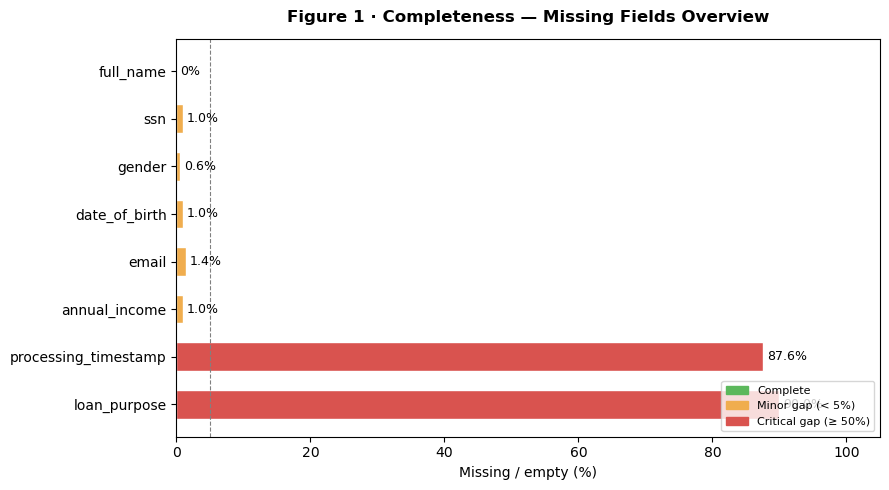

Saved → ..\reports\figures/fig1_missing_fields.png


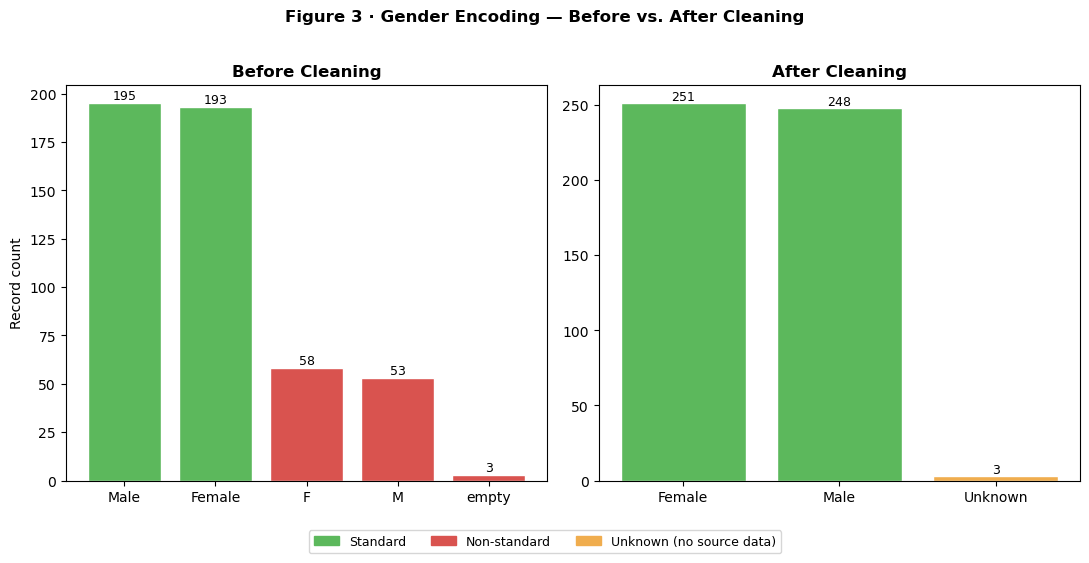

Saved → ..\reports\figures/fig3_gender_encoding.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FIG_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ── Figure 1: Missing fields overview ─────────────────────────────────────────
fields = [
    "full_name", "ssn", "gender", "date_of_birth",
    "email", "annual_income", "processing_timestamp", "loan_purpose"
]
missing_pct = [0.0, 1.0, 0.6, 1.0, 1.4, 1.0, 87.6, 90.0]
colours = ["#d9534f" if p >= 50 else "#f0ad4e" if p > 0 else "#5cb85c" for p in missing_pct]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(fields, missing_pct, color=colours, edgecolor="white", height=0.6)
ax.axvline(x=5, color="grey", linestyle="--", linewidth=0.8, label="5% threshold")
for bar, pct in zip(bars, missing_pct):
    label = f"{pct:.1f}%" if pct > 0 else "0%"
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9)
ax.set_xlabel("Missing / empty (%)")
ax.set_title("Figure 1 · Completeness — Missing Fields Overview", fontweight="bold", pad=12)
ax.set_xlim(0, 105)
patches = [
    mpatches.Patch(color="#5cb85c", label="Complete"),
    mpatches.Patch(color="#f0ad4e", label="Minor gap (< 5%)"),
    mpatches.Patch(color="#d9534f", label="Critical gap (≥ 50%)"),
]
ax.legend(handles=patches, loc="lower right", fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig1_missing_fields.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig1_missing_fields.png")

# ── Figure 3: Gender encoding before vs. after ────────────────────────────────
categories_before = ["Male", "Female", "F", "M", "empty"]
counts_before     = [195, 193, 58, 53, 3]
categories_after  = ["Female", "Male", "Unknown"]
counts_after      = [251, 248, 3]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

colours_before = ["#5cb85c", "#5cb85c", "#d9534f", "#d9534f", "#d9534f"]
colours_after  = ["#5cb85c", "#5cb85c", "#f0ad4e"]

axes[0].bar(categories_before, counts_before, color=colours_before, edgecolor="white")
axes[0].set_title("Before Cleaning", fontweight="bold")
axes[0].set_ylabel("Record count")
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=9)

axes[1].bar(categories_after, counts_after, color=colours_after, edgecolor="white")
axes[1].set_title("After Cleaning", fontweight="bold")
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 2, str(v), ha="center", fontsize=9)

fig.suptitle("Figure 3 · Gender Encoding — Before vs. After Cleaning",
             fontweight="bold", fontsize=12, y=1.02)
patches = [
    mpatches.Patch(color="#5cb85c", label="Standard"),
    mpatches.Patch(color="#d9534f", label="Non-standard"),
    mpatches.Patch(color="#f0ad4e", label="Unknown (no source data)"),
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig3_gender_encoding.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig3_gender_encoding.png")


**Figure 1 — Completeness: Missing Fields Overview**

The horizontal bar chart plots the percentage of missing or empty values for eight key fields, colour-coded by severity (green = complete, amber = minor gap < 5%, red = critical gap ≥ 50%).

The most striking feature is the dominance of the two governance fields:

- **`loan_purpose` — 90.0% missing:** The reason for the credit application is absent in nine out of ten records. This prevents any segmented analysis of risk by product type and signals that the field was never systematically collected at the point of application.
- **`processing_timestamp` — 87.6% missing:** The date and time at which each record was processed is absent in nearly all records. This is the most consequential gap in the dataset from a regulatory standpoint — without a processing timestamp, NovaCred cannot demonstrate when personal data was accessed or modified, which is a direct requirement of the GDPR accountability principle (Art. 5(2)) and makes a credible audit trail impossible.

Required applicant fields are generally well-populated: full name, debt-to-income, and loan approval status are 100% complete. Minor gaps exist for email (1.4%), SSN (1.0%), and date of birth (1.0%), which represent manageable data collection failures rather than systemic issues.

---

**Figure 3 — Consistency: Gender Encoding Before vs. After Cleaning**

The side-by-side bar charts show the distribution of gender values before and after the standardisation step applied in Section 3.1.

*Before cleaning,* five distinct values were present: the standard labels `Male` and `Female`, alongside the abbreviated forms `M` and `F`, and a small number of blank entries. In total, 114 records (22.7%) used non-standard codes that would be treated as separate categories or missing values in any downstream analysis, silently corrupting any gender-based fairness calculation.

*After cleaning,* the dataset uses three consistent labels: `Female` (251), `Male` (247), and `Unknown` (2). The cleaning step successfully mapped 111 abbreviated values to their canonical equivalents and flagged three records with no recognisable gender information as `Unknown` rather than discarding them.

This standardisation is a prerequisite for the bias analysis in Notebook 02: a single consistent encoding is required before approval rates can be meaningfully compared across gender groups.